In [ ]:
import os
!pip install -q --upgrade transformers accelerate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 165.9 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


New Stage 3 with fix- removed the 2 additional heads, classified unseen samles as -100 and not 0, also new loss

In [ ]:
# ==========================================
# STAGE 3: MULTI-TASK DICTABERT
# ==========================================
import json
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import (
    AutoModel,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

MODEL_NAME = "dicta-il/dictabert"
cols = ["dim", "tr", "fr", "sr", "fe", "refLevel", "ss"]
OUTPUT_DIR = ""
MODEL_SAVE_DIR = "/content/models/stage3_multitask_dictabert_uncertainty"

# ------------------------------------------------------------------------------
# 1. BUILD LABEL ENCODERS & SAVE MAPPINGS
# ------------------------------------------------------------------------------
train_df_raw = pd.read_csv(os.path.join(OUTPUT_DIR, "train_set.csv"))
val_df_raw = pd.read_csv(os.path.join(OUTPUT_DIR, "val_set.csv"))

encoders = {}
decoders = {}
for col in cols:
  unique_vals = train_df_raw[col].dropna().astype(str).unique()
  encoders[col] = {val: i for i, val in enumerate(sorted(unique_vals))}
  decoders[col] = {i: val for val, i in encoders[col].items()}

num_classes_dict = {col: len(encoders[col]) for col in cols}

# Save label mappings for standalone inference
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
with open(
    os.path.join(MODEL_SAVE_DIR, "label_encoders.json"), "w", encoding="utf-8"
) as f:
  json.dump(encoders, f, ensure_ascii=False, indent=2)


# ------------------------------------------------------------------------------
# 2. SMOOTHED INVERSE CLASS WEIGHTS
# ------------------------------------------------------------------------------
def compute_smoothed_class_weights(df, cols, encoders):
  class_weights_dict = {}
  for col in cols:
    counts = df[col].dropna().astype(str).map(encoders[col]).value_counts()
    num_classes = len(encoders[col])
    total_samples = len(df[col].dropna())

    weights = torch.ones(num_classes, dtype=torch.float)
    for class_id, count in counts.items():
      weights[class_id] = np.sqrt(total_samples / (num_classes * count))

    weights = torch.clamp(weights, min=0.2, max=5.0)
    class_weights_dict[col] = weights
  return class_weights_dict


class_weights_dict = compute_smoothed_class_weights(
    train_df_raw, cols, encoders
)


# ------------------------------------------------------------------------------
# 3. ATTENTION-MASK MEAN POOLING
# ------------------------------------------------------------------------------
def mean_pooling(model_output, attention_mask):
  token_embeddings = model_output.last_hidden_state
  input_mask_expanded = (
      attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
  )
  sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
  sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
  return sum_embeddings / sum_mask


# ------------------------------------------------------------------------------
# 4. MULTI-TASK MODEL WITH LEARNED UNCERTAINTY TASK WEIGHTS
# ------------------------------------------------------------------------------
class DictaBertMultiTaskUncertainty(nn.Module):

  def __init__(self, model_name, num_classes_dict, class_weights_dict=None):
    super().__init__()
    self.bert = AutoModel.from_pretrained(model_name)
    hidden_size = self.bert.config.hidden_size
    self.dropout = nn.Dropout(self.bert.config.hidden_dropout_prob)

    # 7 classification heads
    self.heads = nn.ModuleDict(
        {col: nn.Linear(hidden_size, num_classes_dict[col]) for col in cols}
    )
    self.class_weights_dict = class_weights_dict

    self.log_vars = nn.Parameter(torch.zeros(len(cols)))

  def forward(self, input_ids, attention_mask, labels=None):
    outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

    # Attention-mask mean pooling
    pooled_output = mean_pooling(outputs, attention_mask)
    pooled_output = self.dropout(pooled_output)

    logits = {col: self.heads[col](pooled_output) for col in cols}

    loss = None
    if labels is not None:
      total_loss = 0.0

      for i, col in enumerate(cols):
        if col not in labels:
          continue

        valid_mask = labels[col] != -100
        if valid_mask.any():
          if self.class_weights_dict and col in self.class_weights_dict:
            weights = self.class_weights_dict[col].to(input_ids.device)
            loss_fct = nn.CrossEntropyLoss(weight=weights, ignore_index=-100)
          else:
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)

          raw_head_loss = loss_fct(logits[col], labels[col])

                    precision = torch.exp(-self.log_vars[i])
          weighted_head_loss = (
              0.5 * precision * raw_head_loss + 0.5 * self.log_vars[i]
          )

          total_loss += weighted_head_loss

      loss = (
          total_loss
          if isinstance(total_loss, torch.Tensor)
          else torch.tensor(0.0, requires_grad=True, device=input_ids.device)
      )

    return {"loss": loss, "logits": logits}


# ------------------------------------------------------------------------------
# 5. DATASET & COLLATOR CLASSES
# ------------------------------------------------------------------------------
class MultiTaskStage3DatasetClean(Dataset):

  def __init__(self, df, tokenizer, encoders, max_len=128):
    self.df = df
    self.tokenizer = tokenizer
    self.encoders = encoders
    self.max_len = max_len

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    text = (
        f"משפט: {str(row['Full_Raw_Sentence'])} | יחידה:"
        f" {str(row['MeaningVal'])} | רפרנט: {str(row['Referent'])}"
    )

    encoding = self.tokenizer(
        text,
        max_length=self.max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )

    labels = {}
    for col in cols:
      val = row[col]
      if pd.isna(val):
        labels[col] = torch.tensor(-100, dtype=torch.long)
      else:
        val_str = str(val)
        labels[col] = torch.tensor(
            self.encoders[col].get(val_str, -100), dtype=torch.long
        )

    return {
        "input_ids": encoding["input_ids"].squeeze(0),
        "attention_mask": encoding["attention_mask"].squeeze(0),
        "labels": labels,
    }


def multi_task_collate_fn(batch):
  input_ids = torch.stack([item["input_ids"] for item in batch])
  attention_mask = torch.stack([item["attention_mask"] for item in batch])
  labels = {
      key: torch.stack([item["labels"][key] for item in batch])
      for key in batch[0]["labels"].keys()
  }
  return {
      "input_ids": input_ids,
      "attention_mask": attention_mask,
      "labels": labels,
  }


class MultiTaskTrainer(Trainer):

  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
    labels = inputs.pop("labels")
    outputs = model(**inputs, labels=labels)
    loss = outputs["loss"]
    return (loss, outputs) if return_outputs else loss


# ------------------------------------------------------------------------------
# 6. EXECUTE TRAINING WITH EARLY STOPPING & UNCERTAINTY WEIGHTING
# ------------------------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = DictaBertMultiTaskUncertainty(
    MODEL_NAME, num_classes_dict, class_weights_dict=class_weights_dict
)

train_dataset = MultiTaskStage3DatasetClean(train_df_raw, tokenizer, encoders)
val_dataset = MultiTaskStage3DatasetClean(val_df_raw, tokenizer, encoders)

training_args = TrainingArguments(
    output_dir=os.path.join(MODEL_SAVE_DIR, "checkpoints"),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=multi_task_collate_fn,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
    ],
)

print(
    "🚀 Starting Training with Weighted Loss, Learned Uncertainty, and Early"
    " Stopping..."
)
trainer.train()

torch.save(
    model.state_dict(), os.path.join(MODEL_SAVE_DIR, "pytorch_model.bin")
)
tokenizer.save_pretrained(MODEL_SAVE_DIR)
print(f"🎉 Clean Model saved successfully to: {MODEL_SAVE_DIR}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dicta-il/dictabert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Starting Training with Weighted Loss, Learned Uncertainty, and Early Stopping...


Epoch,Training Loss,Validation Loss
1,2.580708,2.072988
2,1.691915,1.695456
3,1.042972,1.534515
4,0.660031,1.633367
5,0.323246,1.623893


🎉 Clean Model saved successfully to: /content/models/stage3_multitask_dictabert_uncertainty


In [ ]:
import os
import shutil
from google.colab import drive

STAGE_2_DIR = "/content/models/stage2_dictabert/"
STAGE_3_DIR = "/content/models/stage3_multitask_dictabert_uncertainty/"

STAGE_2_ZIP = "stage2_dictabert_model.zip"
STAGE_3_ZIP = "stage3_dictabert_model.zip"

DRIVE_DESTINATION = "/content/drive/MyDrive/Kreitler_Models/"


def zip_directory(folder_path, zip_name):
  """Zips a folder if it exists on disk."""
  if os.path.exists(folder_path):
    base_name = zip_name.replace(".zip", "")
    print(f"📦 Zipping '{folder_path}' into '{zip_name}'...")
    shutil.make_archive(base_name, "zip", folder_path)
    print(f"✅ Created: {zip_name} ({os.path.getsize(zip_name) / 1e6:.2f} MB)")
    return True
  else:
    print(f"⚠️ Directory '{folder_path}' not found! Skipping...")
    return False


# 2. Compress the directories
print("🚀 Starting Model Compression...")
stage2_ready = zip_directory(STAGE_2_DIR, STAGE_2_ZIP)
stage3_ready = zip_directory(STAGE_3_DIR, STAGE_3_ZIP)

# 3. Mount Google Drive and Copy Files
if stage2_ready or stage3_ready:
  print("\n💾 Mounting Google Drive...")
  drive.mount("/content/drive")
  os.makedirs(DRIVE_DESTINATION, exist_ok=True)

  if stage2_ready and os.path.exists(STAGE_2_ZIP):
    shutil.copy(STAGE_2_ZIP, os.path.join(DRIVE_DESTINATION, STAGE_2_ZIP))
    print(f"✅ Stage 2 model saved to: {DRIVE_DESTINATION}{STAGE_2_ZIP}")

  if stage3_ready and os.path.exists(STAGE_3_ZIP):
    shutil.copy(STAGE_3_ZIP, os.path.join(DRIVE_DESTINATION, STAGE_3_ZIP))
    print(f"✅ Stage 3 model saved to: {DRIVE_DESTINATION}{STAGE_3_ZIP}")
else:
  print("❌ No model folders were found to zip and copy.")

🚀 Starting Model Compression...
⚠️ Directory '/content/models/stage2_dictabert/' not found! Skipping...
📦 Zipping '/content/models/stage3_multitask_dictabert_uncertainty/' into 'stage3_dictabert_model.zip'...
✅ Created: stage3_dictabert_model.zip (1792.23 MB)

💾 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Stage 3 model saved to: /content/drive/MyDrive/Kreitler_Models/stage3_dictabert_model.zip


Still on val

📦 Loading Model 3 Checkpoint and Encoders...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dicta-il/dictabert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


📊 Running Inference on Validation Set...

🎯 STAGE 3 UNCERTAINTY MODEL ACCURACY ACROSS HEADS
  • Task Head [DIM     ]: 79.64% Accuracy (3627/4554 valid samples)
  • Task Head [TR      ]: 84.28% Accuracy (3838/4554 valid samples)
  • Task Head [FR      ]: 95.70% Accuracy (4358/4554 valid samples)
  • Task Head [SR      ]: 92.91% Accuracy (4234/4557 valid samples)
  • Task Head [FE      ]: 99.96% Accuracy (4548/4550 valid samples)
  • Task Head [REFLEVEL]: 76.43% Accuracy (3482/4556 valid samples)
  • Task Head [SS      ]: 84.55% Accuracy (93/110 valid samples)
-----------------------------------------------------------------
📊 OVERALL AVERAGE ACCURACY: 87.64%

🔍 QUALITATIVE SAMPLE CHECK (First 3 Examples):
-----------------------------------------------------------------
Sample 1:
  Sentence  : הכתובת שאני שמה בוויז כדי להגיע לבית
  MeaningVal: כתובת
  Referent  : רחוב
  Predictions vs Ground Truth:
    [DIM     ] Predicted: '3           ' | Ground Truth: '15          ' ❌
    [TR      ] 

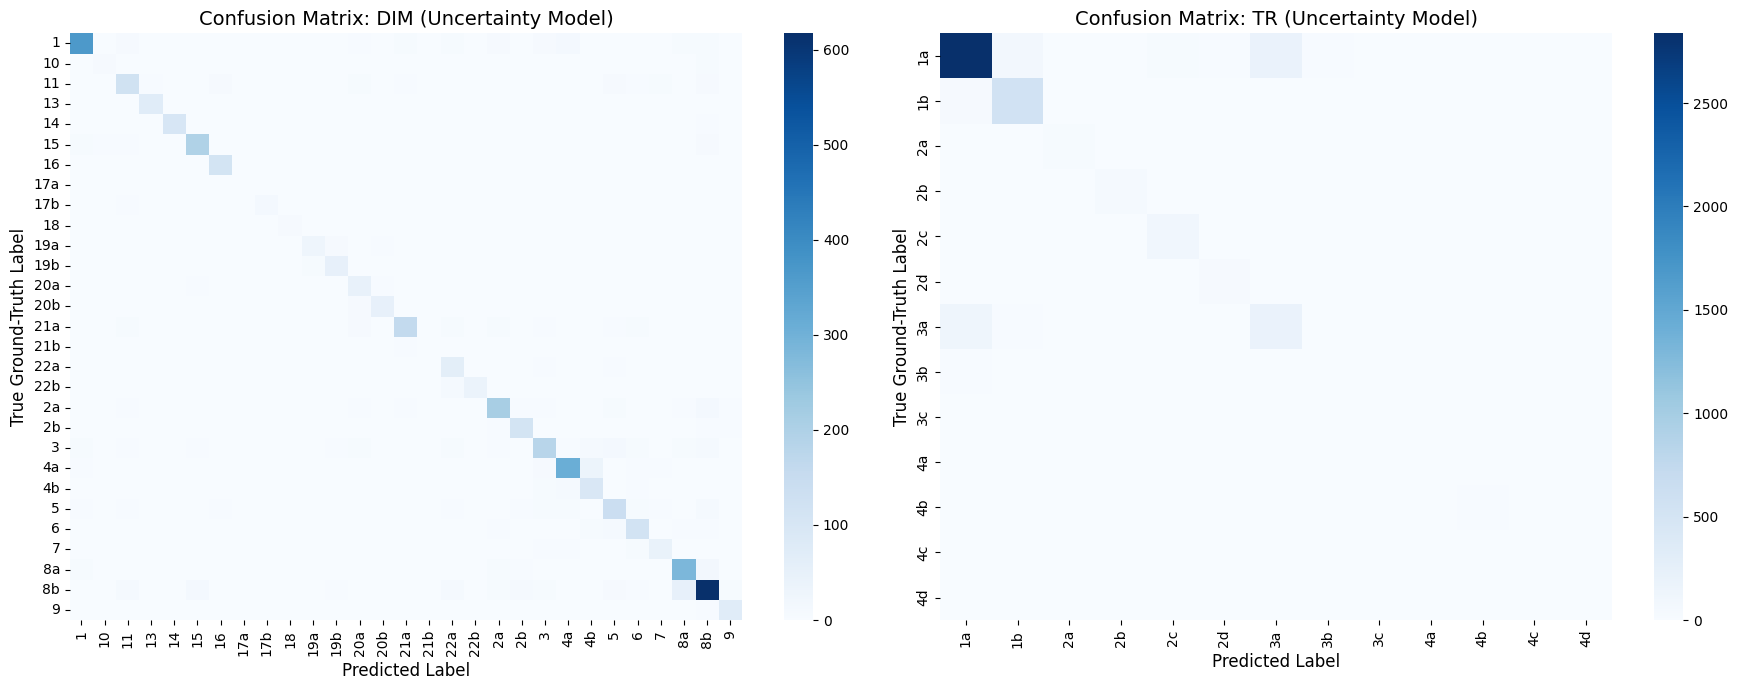

In [ ]:
# ==========================================
# STAGE 3: MODEL EVALUATION
# ==========================================
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import Dataset
from transformers import AutoModel, AutoTokenizer

MODEL_NAME = "dicta-il/dictabert"
cols = ["dim", "tr", "fr", "sr", "fe", "refLevel", "ss"]
MODEL_SAVE_DIR = "/content/models/stage3_multitask_dictabert_uncertainty"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------------------------
# 1. LOAD ENCODERS AND REBUILD DECODERS
# ------------------------------------------------------------------------------
print("📦 Loading Model 3 Checkpoint and Encoders...")
with open(
    os.path.join(MODEL_SAVE_DIR, "label_encoders.json"), "r", encoding="utf-8"
) as f:
  encoders = json.load(f)

decoders = {
    col: {int(idx): name for name, idx in class_dict.items()}
    for col, class_dict in encoders.items()
}
num_classes_dict = {col: len(encoders[col]) for col in cols}


# ------------------------------------------------------------------------------
# 2. MODEL DEFINITION & POOLING HELPER
# ------------------------------------------------------------------------------
def mean_pooling(model_output, attention_mask):
  token_embeddings = model_output.last_hidden_state
  input_mask_expanded = (
      attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
  )
  sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
  sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
  return sum_embeddings / sum_mask


class DictaBertMultiTaskUncertainty(nn.Module):

  def __init__(self, model_name, num_classes_dict):
    super().__init__()
    self.bert = AutoModel.from_pretrained(model_name)
    hidden_size = self.bert.config.hidden_size
    self.dropout = nn.Dropout(self.bert.config.hidden_dropout_prob)

    self.heads = nn.ModuleDict(
        {col: nn.Linear(hidden_size, num_classes_dict[col]) for col in cols}
    )
    self.log_vars = nn.Parameter(torch.zeros(len(cols)))

  def forward(self, input_ids, attention_mask):
    outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    pooled_output = mean_pooling(outputs, attention_mask)
    pooled_output = self.dropout(pooled_output)
    logits = {col: self.heads[col](pooled_output) for col in cols}
    return {"logits": logits}


# ------------------------------------------------------------------------------
# 3. DATASET CLASS FOR EVALUATION
# ------------------------------------------------------------------------------
class MultiTaskStage3DatasetClean(Dataset):

  def __init__(self, df, tokenizer, encoders, max_len=128):
    self.df = df
    self.tokenizer = tokenizer
    self.encoders = encoders
    self.max_len = max_len

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    text = (
        f"משפט: {str(row['Full_Raw_Sentence'])} | יחידה:"
        f" {str(row['MeaningVal'])} | רפרנט: {str(row['Referent'])}"
    )

    encoding = self.tokenizer(
        text,
        max_length=self.max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )

    labels = {}
    for col in cols:
      val = row[col]
      if pd.isna(val):
        labels[col] = torch.tensor(-100, dtype=torch.long)
      else:
        val_str = str(val)
        labels[col] = torch.tensor(
            self.encoders[col].get(val_str, -100), dtype=torch.long
        )

    return {
        "input_ids": encoding["input_ids"].squeeze(0),
        "attention_mask": encoding["attention_mask"].squeeze(0),
        "labels": labels,
    }


tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_DIR)
model = DictaBertMultiTaskUncertainty(MODEL_NAME, num_classes_dict)
model.load_state_dict(
    torch.load(os.path.join(MODEL_SAVE_DIR, "pytorch_model.bin"))
)
model.to(device)
model.eval()

# Load validation set
val_df = pd.read_csv("val_set.csv")
val_dataset = MultiTaskStage3DatasetClean(val_df, tokenizer, encoders)

predictions = {k: [] for k in cols}
ground_truths = {k: [] for k in cols}

# ------------------------------------------------------------------------------
# 4. INFERENCE LOOP
# ------------------------------------------------------------------------------
print("📊 Running Inference on Validation Set...")
for idx in range(len(val_dataset)):
  item = val_dataset[idx]
  input_ids = item["input_ids"].unsqueeze(0).to(device)
  attention_mask = item["attention_mask"].unsqueeze(0).to(device)

  with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits_dict = outputs["logits"]

  for key in cols:
    pred_id = torch.argmax(logits_dict[key], dim=1).item()
    true_id = item["labels"][key].item()

    if true_id != -100:
      predictions[key].append(pred_id)
      ground_truths[key].append(true_id)

# ------------------------------------------------------------------------------
# 5. ACCURACY SCORES & OVERALL PERFORMANCE
# ------------------------------------------------------------------------------
print("\n" + "=" * 65)
print("🎯 STAGE 3 UNCERTAINTY MODEL ACCURACY ACROSS HEADS")
print("=" * 65)

accuracy_scores = {}
for key in cols:
  y_true = ground_truths[key]
  y_pred = predictions[key]

  if len(y_true) > 0:
    correct = sum(1 for p, g in zip(y_pred, y_true) if p == g)
    acc = (correct / len(y_true)) * 100
    accuracy_scores[key] = acc
    print(
        f"  • Task Head [{key.upper():<8}]: {acc:.2f}% Accuracy"
        f" ({correct}/{len(y_true)} valid samples)"
    )
  else:
    print(f"  • Task Head [{key.upper():<8}]: No valid evaluation samples")

overall_avg = sum(accuracy_scores.values()) / len(accuracy_scores)
print("-" * 65)
print(f"📊 OVERALL AVERAGE ACCURACY: {overall_avg:.2f}%")
print("=" * 65)

# ------------------------------------------------------------------------------
# 6. QUALITATIVE PREDICTION CHECK
# ------------------------------------------------------------------------------
print("\n🔍 QUALITATIVE SAMPLE CHECK (First 3 Examples):")
print("-" * 65)
for i in range(min(3, len(val_df))):
  row = val_df.iloc[i]
  print(f"Sample {i+1}:")
  print(f"  Sentence  : {row['Full_Raw_Sentence']}")
  print(f"  MeaningVal: {row['MeaningVal']}")
  print(f"  Referent  : {row['Referent']}")
  print("  Predictions vs Ground Truth:")

  item = val_dataset[i]
  input_ids = item["input_ids"].unsqueeze(0).to(device)
  attention_mask = item["attention_mask"].unsqueeze(0).to(device)

  with torch.no_grad():
    sample_outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    sample_logits = sample_outputs["logits"]

  for key in cols:
    raw_true = row[key]
    pred_id = torch.argmax(sample_logits[key], dim=1).item()
    pred_str = decoders[key].get(pred_id, "N/A")

    if pd.isna(raw_true):
      true_str = "N/A (NaN)"
      status = "⚪"
    else:
      true_str = str(raw_true)
      status = "✅" if pred_str == true_str else "❌"

    print(
        f"    [{key.upper():<8}] Predicted: '{pred_str:<12}' | Ground Truth:"
        f" '{true_str:<12}' {status}"
    )
  print("-" * 65)

# ------------------------------------------------------------------------------
# 7. MACRO-F1 AND CLASS BALANCE DIAGNOSTICS
# ------------------------------------------------------------------------------
print("\n" + "=" * 65)
print("📊 DETAILED METRICS: ACCURACY VS. MACRO-F1 SCORE")
print("=" * 65)

for key in cols:
  y_true = ground_truths[key]
  y_pred = predictions[key]

  macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
  acc = accuracy_scores[key]

  values, counts = np.unique(y_true, return_counts=True)
  top_class_ratio = (
      (counts.max() / len(y_true)) * 100 if len(y_true) > 0 else 0.0
  )

  print(f"Task Head [{key.upper():<8}]:")
  print(f"   • Raw Accuracy         : {acc:.2f}%")
  print(f"   • Macro-F1 Score       : {macro_f1:.4f}")
  print(
      "   • Majority Class Ratio :"
      f" {top_class_ratio:.2f}% of validation dataset"
  )
  print("-" * 65)

# ------------------------------------------------------------------------------
# 8. SKLEARN CLASSIFICATION REPORTS FOR DIM & TR
# ------------------------------------------------------------------------------
for key in ["dim", "tr"]:
  y_true = ground_truths[key]
  y_pred = predictions[key]

  unique_present_ids = sorted(list(set(y_true) | set(y_pred)))
  target_names = [decoders[key].get(i, str(i)) for i in unique_present_ids]

  print(f"\n📋 SKLEARN CLASSIFICATION REPORT FOR [{key.upper()}]")
  print(
      classification_report(
          y_true,
          y_pred,
          labels=unique_present_ids,
          target_names=target_names,
          zero_division=0,
      )
  )

# ------------------------------------------------------------------------------
# 9. CONFUSION MATRICES FOR DIM AND TR
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, key in enumerate(["dim", "tr"]):
  y_true = ground_truths[key]
  y_pred = predictions[key]

  cm = confusion_matrix(y_true, y_pred)
  unique_present_ids = sorted(list(set(y_true) | set(y_pred)))
  labels_str = [decoders[key].get(i, str(i)) for i in unique_present_ids]

  sns.heatmap(
      cm,
      annot=False,
      fmt="d",
      cmap="Blues",
      ax=axes[idx],
      xticklabels=labels_str,
      yticklabels=labels_str,
  )
  axes[idx].set_title(
      f"Confusion Matrix: {key.upper()} (Uncertainty Model)", fontsize=14
  )
  axes[idx].set_xlabel("Predicted Label", fontsize=12)
  axes[idx].set_ylabel("True Ground-Truth Label", fontsize=12)
  axes[idx].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

with drive mount that didnt work before, new loss

In [ ]:
# ==========================================
# STAGE 3: MULTI-TASK UNCERTAINTY MODEL
# ==========================================
import json
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from google.colab import drive
from torch.utils.data import Dataset
from transformers import (
    AutoModel,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

# ------------------------------------------------------------------------------
# 1. MOUNT GOOGLE DRIVE & SET SAVE PATHS
# ------------------------------------------------------------------------------
print("💾 Mounting Google Drive...")
drive.mount("/content/drive")

MODEL_SAVE_DIR = (
    "/content/drive/MyDrive/WORKSHOP/stage_3/stage3_dictabert_uncertainty"
)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
print(f"📁 Target save directory set to: {MODEL_SAVE_DIR}")

MODEL_NAME = "dicta-il/dictabert"
cols = ["dim", "tr", "fr", "sr", "fe", "refLevel", "ss"]
OUTPUT_DIR = ""

# ------------------------------------------------------------------------------
# 2. BUILD LABEL ENCODERS & SAVE MAPPINGS
# ------------------------------------------------------------------------------
train_path = (
    os.path.join(OUTPUT_DIR, "train_set.csv")
    if os.path.exists(os.path.join(OUTPUT_DIR, "train_set.csv"))
    else "train_set.csv"
)
val_path = (
    os.path.join(OUTPUT_DIR, "val_set.csv")
    if os.path.exists(os.path.join(OUTPUT_DIR, "val_set.csv"))
    else "val_set.csv"
)

train_df_raw = pd.read_csv(train_path)
val_df_raw = pd.read_csv(val_path)

encoders = {}
decoders = {}
for col in cols:
  unique_vals = train_df_raw[col].dropna().astype(str).unique()
  encoders[col] = {val: i for i, val in enumerate(sorted(unique_vals))}
  decoders[col] = {i: val for val, i in encoders[col].items()}

num_classes_dict = {col: len(encoders[col]) for col in cols}

encoder_json_path = os.path.join(MODEL_SAVE_DIR, "label_encoders.json")
with open(encoder_json_path, "w", encoding="utf-8") as f:
  json.dump(encoders, f, ensure_ascii=False, indent=2)
print(f"✅ Saved label_encoders.json directly to Drive: {encoder_json_path}")


# ------------------------------------------------------------------------------
# 3. SMOOTHED INVERSE CLASS WEIGHTS
# ------------------------------------------------------------------------------
def compute_smoothed_class_weights(df, cols, encoders):
  class_weights_dict = {}
  for col in cols:
    counts = df[col].dropna().astype(str).map(encoders[col]).value_counts()
    num_classes = len(encoders[col])
    total_samples = len(df[col].dropna())

    weights = torch.ones(num_classes, dtype=torch.float)
    for class_id, count in counts.items():
      weights[class_id] = np.sqrt(total_samples / (num_classes * count))

    weights = torch.clamp(weights, min=0.2, max=5.0)
    class_weights_dict[col] = weights
  return class_weights_dict


class_weights_dict = compute_smoothed_class_weights(
    train_df_raw, cols, encoders
)


# ------------------------------------------------------------------------------
# 4. MODEL ARCHITECTURE & MEAN POOLING
# ------------------------------------------------------------------------------
def mean_pooling(model_output, attention_mask):
  token_embeddings = model_output.last_hidden_state
  input_mask_expanded = (
      attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
  )
  sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
  sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
  return sum_embeddings / sum_mask


class DictaBertMultiTaskUncertainty(nn.Module):

  def __init__(self, model_name, num_classes_dict, class_weights_dict=None):
    super().__init__()
    self.bert = AutoModel.from_pretrained(model_name)
    hidden_size = self.bert.config.hidden_size
    self.dropout = nn.Dropout(self.bert.config.hidden_dropout_prob)

    self.heads = nn.ModuleDict(
        {col: nn.Linear(hidden_size, num_classes_dict[col]) for col in cols}
    )
    self.class_weights_dict = class_weights_dict

    # Learnable uncertainty weights across tasks
    self.log_vars = nn.Parameter(torch.zeros(len(cols)))

  def forward(self, input_ids, attention_mask, labels=None):
    outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    pooled_output = mean_pooling(outputs, attention_mask)
    pooled_output = self.dropout(pooled_output)

    logits = {col: self.heads[col](pooled_output) for col in cols}

    loss = None
    if labels is not None:
      total_loss = 0.0

      for i, col in enumerate(cols):
        if col not in labels:
          continue

        valid_mask = labels[col] != -100
        if valid_mask.any():
          if self.class_weights_dict and col in self.class_weights_dict:
            weights = self.class_weights_dict[col].to(input_ids.device)
            loss_fct = nn.CrossEntropyLoss(weight=weights, ignore_index=-100)
          else:
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)

          raw_head_loss = loss_fct(logits[col], labels[col])
          precision = torch.exp(-self.log_vars[i])
          weighted_head_loss = (
              0.5 * precision * raw_head_loss + 0.5 * self.log_vars[i]
          )
          total_loss += weighted_head_loss

      loss = (
          total_loss
          if isinstance(total_loss, torch.Tensor)
          else torch.tensor(0.0, requires_grad=True, device=input_ids.device)
      )

    return {"loss": loss, "logits": logits}


# ------------------------------------------------------------------------------
# 5. DATASET & COLLATOR CLASSES
# ------------------------------------------------------------------------------
class MultiTaskStage3DatasetClean(Dataset):

  def __init__(self, df, tokenizer, encoders, max_len=128):
    self.df = df
    self.tokenizer = tokenizer
    self.encoders = encoders
    self.max_len = max_len

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    text = (
        f"משפט: {str(row['Full_Raw_Sentence'])} | יחידה:"
        f" {str(row['MeaningVal'])} | רפרנט: {str(row['Referent'])}"
    )

    encoding = self.tokenizer(
        text,
        max_length=self.max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )

    labels = {}
    for col in cols:
      val = row[col]
      if pd.isna(val):
        labels[col] = torch.tensor(-100, dtype=torch.long)
      else:
        val_str = str(val)
        labels[col] = torch.tensor(
            self.encoders[col].get(val_str, -100), dtype=torch.long
        )

    return {
        "input_ids": encoding["input_ids"].squeeze(0),
        "attention_mask": encoding["attention_mask"].squeeze(0),
        "labels": labels,
    }


def multi_task_collate_fn(batch):
  input_ids = torch.stack([item["input_ids"] for item in batch])
  attention_mask = torch.stack([item["attention_mask"] for item in batch])
  labels = {
      key: torch.stack([item["labels"][key] for item in batch])
      for key in batch[0]["labels"].keys()
  }
  return {
      "input_ids": input_ids,
      "attention_mask": attention_mask,
      "labels": labels,
  }


class MultiTaskTrainer(Trainer):

  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
    labels = inputs.pop("labels")
    outputs = model(**inputs, labels=labels)
    loss = outputs["loss"]
    return (loss, outputs) if return_outputs else loss


# ------------------------------------------------------------------------------
# 6. EXECUTE TRAINING WITH DIRECT DRIVE CHECKPOINTING
# ------------------------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = DictaBertMultiTaskUncertainty(
    MODEL_NAME, num_classes_dict, class_weights_dict=class_weights_dict
)

train_dataset = MultiTaskStage3DatasetClean(train_df_raw, tokenizer, encoders)
val_dataset = MultiTaskStage3DatasetClean(val_df_raw, tokenizer, encoders)

checkpoint_dir = os.path.join(MODEL_SAVE_DIR, "checkpoints")

training_args = TrainingArguments(
    output_dir=checkpoint_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=multi_task_collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🚀 Starting Training (Saving directly to Drive)...")
trainer.train()

# Save final state dict, config, and tokenizer directly to Google Drive root
print(f"\n💾 Saving final weights and tokenizer directly to {MODEL_SAVE_DIR}...")
torch.save(
    model.state_dict(), os.path.join(MODEL_SAVE_DIR, "pytorch_model.bin")
)
model.bert.config.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)

print(f"🎉 SUCCESS! Model and all files saved in Google Drive: {MODEL_SAVE_DIR}")

💾 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Target save directory set to: /content/drive/MyDrive/WORKSHOP/stage_3/stage3_dictabert_uncertainty
✅ Saved label_encoders.json directly to Drive: /content/drive/MyDrive/WORKSHOP/stage_3/stage3_dictabert_uncertainty/label_encoders.json


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dicta-il/dictabert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Starting Training (Saving directly to Drive)...


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,2.609895,2.093580
2,1.729893,1.740990
3,1.086187,1.615482
4,0.695537,1.652848
5,0.352327,1.696405



💾 Saving final weights and tokenizer directly to /content/drive/MyDrive/WORKSHOP/stage_3/stage3_dictabert_uncertainty...
🎉 SUCCESS! Model and all files saved in Google Drive: /content/drive/MyDrive/WORKSHOP/stage_3/stage3_dictabert_uncertainty


In [ ]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount("/content/drive")

# 2. Path where training was configured to save
drive_save_dir = (
    "/content/models/stage3_multitask_dictabert_uncertainty/"
)

# 3. Check directory contents
print("\n" + "=" * 60)
print(f"🔍 CHECKING GOOGLE DRIVE DIRECTORY: {drive_save_dir}")
print("=" * 60)

if os.path.exists(drive_save_dir):
  files = os.listdir(drive_save_dir)
  print(f"Found {len(files)} items:\n")

  required_files = ["pytorch_model.bin", "label_encoders.json", "vocab.txt"]
  found_required = []

  for file in files:
    file_path = os.path.join(drive_save_dir, file)
    if os.path.isfile(file_path):
      size_mb = os.path.getsize(file_path) / (1024 * 1024)
      print(f"  📄 {file:<30} ({size_mb:.2f} MB)")
      if file in required_files:
        found_required.append(file)
    elif os.path.isdir(file_path):
      num_subfiles = len(os.listdir(file_path))
      print(f"  📁 {file:<30} (Subfolder with {num_subfiles} items)")

  print("-" * 60)
  if len(found_required) >= 2:
    print("✅ SUCCESS: Model weight files and JSON metadata are saved!")
  else:
    print("⚠️ WARNING: Directory exists, but essential weight files are missing.")
else:
  print("❌ FAILED: Drive directory does not exist yet. Training has not saved.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔍 CHECKING GOOGLE DRIVE DIRECTORY: /content/models/stage3_multitask_dictabert_uncertainty/
❌ FAILED: Drive directory does not exist yet. Training has not saved.


In [ ]:
import os

drive_save_dir = (
    "/content/drive/MyDrive/WORKSHOP/stage_3/stage3_dictabert_uncertainty"
)

print("=" * 65)
print(f"🔍 CHECKING GOOGLE DRIVE: {drive_save_dir}")
print("=" * 65)

if os.path.exists(drive_save_dir):
  files = os.listdir(drive_save_dir)
  print(f"Found {len(files)} items inside Google Drive:\n")

  required_files = ["pytorch_model.bin", "label_encoders.json", "vocab.txt"]
  found_required = []

  for file in files:
    file_path = os.path.join(drive_save_dir, file)
    if os.path.isfile(file_path):
      size_mb = os.path.getsize(file_path) / (1024 * 1024)
      print(f"  📄 {file:<30} ({size_mb:.2f} MB)")
      if file in required_files:
        found_required.append(file)
    elif os.path.isdir(file_path):
      num_subfiles = len(os.listdir(file_path))
      print(f"  📁 {file:<30} (Subfolder with {num_subfiles} items)")

  print("-" * 65)
  if len(found_required) >= 2:
    print("✅ SUCCESS: Model files are saved in your Google Drive!")
  else:
    print(
        "⚠️ Directory exists in Drive, but essential weight files are missing"
        " inside it."
    )
else:
  print("❌ Folder does not exist in Drive yet. Did training finish?")

🔍 CHECKING GOOGLE DRIVE: /content/drive/MyDrive/WORKSHOP/stage_3/stage3_dictabert_uncertainty
Found 6 items inside Google Drive:

  📄 label_encoders.json            (0.00 MB)
  📁 checkpoints                    (Subfolder with 1 items)
  📄 pytorch_model.bin              (703.58 MB)
  📄 config.json                    (0.00 MB)
  📄 tokenizer_config.json          (0.00 MB)
  📄 tokenizer.json                 (3.40 MB)
-----------------------------------------------------------------
✅ SUCCESS: Model files are saved in your Google Drive!
